<a target="_blank" href="https://colab.research.google.com/github/ZHAW-ZAV/TSO-FS26-students/blob/main/03_forecasting/03_02_stationarity.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

import statsmodels.api as sm

import sys
import os

IN_COLAB = "google.colab" in sys.modules

file_id_atm = "1pZnA_C3LKTvpYA4_Dzqw1bXQDryy7q9c"

if IN_COLAB:
    path_to_atm = "/content/data/dailyATM.csv"
    os.makedirs(os.path.dirname(path_to_atm), exist_ok=True)
    !gdown "https://drive.google.com/uc?id={file_id_atm}" -O "{path_to_atm}"
else:
    import gdown

    url = f"https://drive.google.com/uc?id={file_id_atm}"
    path_to_atm = "data/dailyATM.csv"
    os.makedirs(os.path.dirname(path_to_atm), exist_ok=True)
    gdown.download(url, path_to_atm, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1pZnA_C3LKTvpYA4_Dzqw1bXQDryy7q9c
To: /Users/wate/Documents/GitHub/TSO-FS26-students/03_forecasting/data/dailyATM.csv
100%|██████████| 12.4k/12.4k [00:00<00:00, 13.5MB/s]


The code above loads the data, don't modify.

---------------

***Notebook starts here***

# Import data from CSV file and plot

In [5]:
# Import data. Note: we set column 'timestamp' as the index of this df!
df = pd.read_csv(
    path_to_atm,
    parse_dates=["timestamp"],
    index_col="timestamp"
)

# make sure index is datetime
df.index = pd.to_datetime(df.index)

# Enforce daily frequency (this fills values for arrivals and departure on missing days with NaN)
df = df.asfreq("D")

# Filter df for time period between January and March
df = df.loc["2024-01-08":"2024-03-23"]

# Display first 5 rows of df
df.head()

,arrivals,departures
timestamp,,
2024-01-08 00:00:00+00:00,114,111
2024-01-09 00:00:00+00:00,77,80
2024-01-10 00:00:00+00:00,73,73
2024-01-11 00:00:00+00:00,89,86
2024-01-12 00:00:00+00:00,121,122


# Time Series Visualization

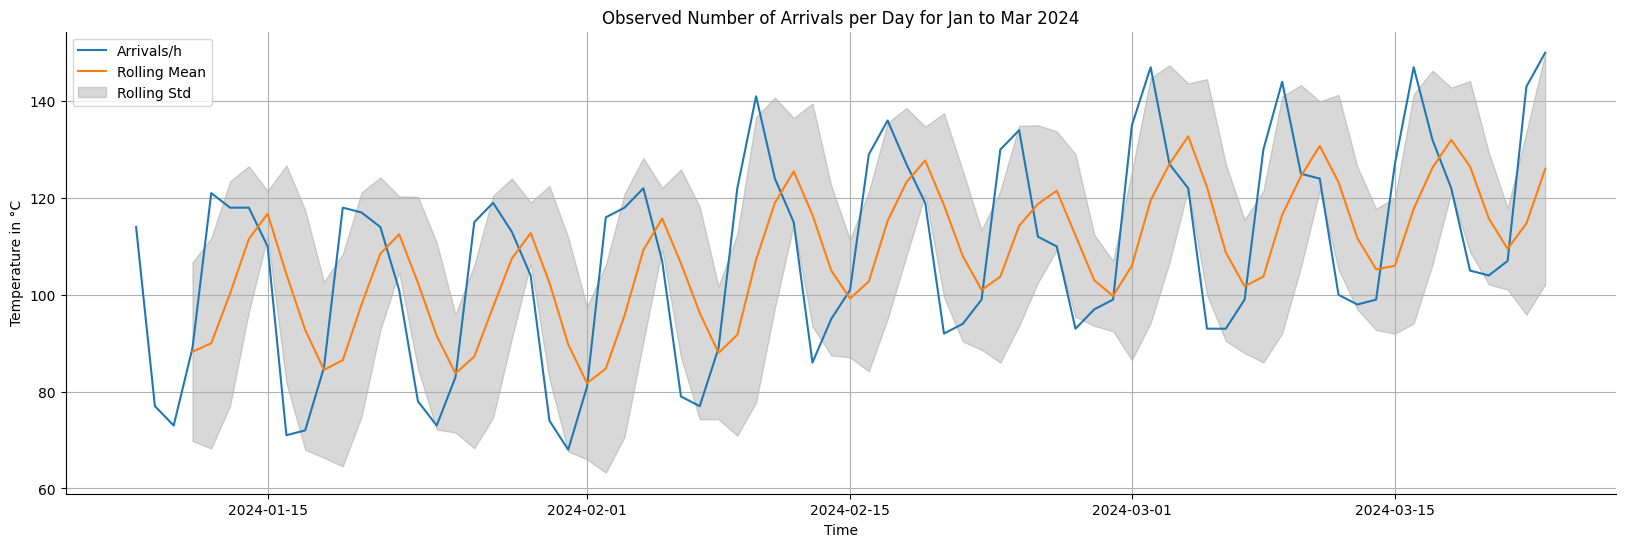

In [6]:
# Calculate the rolling mean and rolling standard deviation for a window of +/- 4hrs
df['arr_Rolling_Mean'] = df['arrivals'].rolling(window=4).mean()
df['arr_Rolling_Std'] = df['arrivals'].rolling(window=4).std()


# Plot the original time series
plt.figure(figsize=(20, 6))
plt.plot(df["arrivals"], label='Arrivals/h')
plt.plot(df["arr_Rolling_Mean"], label='Rolling Mean')
plt.fill_between(df.index, 
                 df["arr_Rolling_Mean"] + df["arr_Rolling_Std"],
                 df["arr_Rolling_Mean"] - df["arr_Rolling_Std"], 
                 color="gray", 
                 alpha=0.3, 
                 label="Rolling Std")
plt.title("Observed Number of Arrivals per Day for Jan to Mar 2024")
plt.xlabel('Time')
plt.ylabel('Temperature in °C')
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.legend()
plt.show()

# Autocorrelation Plot (ACF)

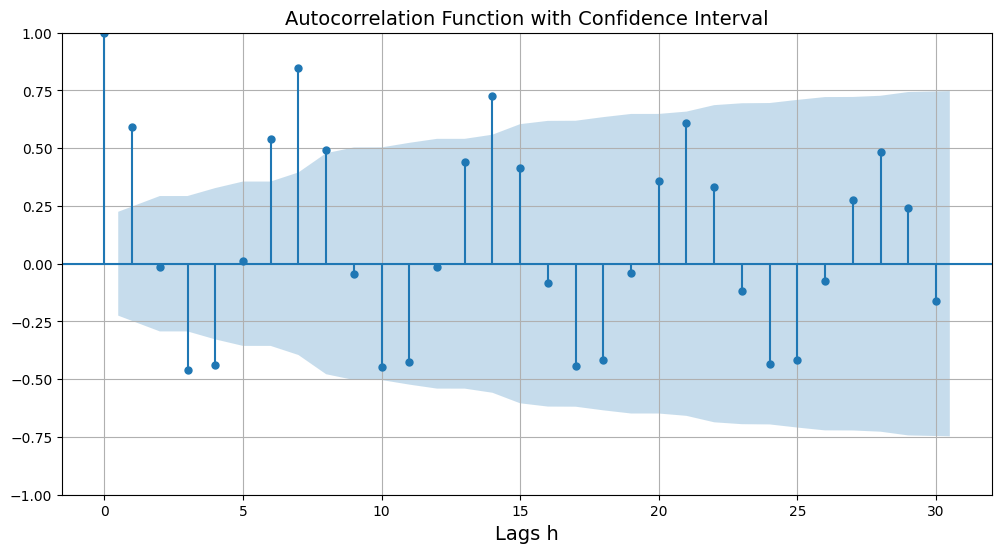

In [7]:
# import the autocorrelation function plot
from statsmodels.graphics.tsaplots import plot_acf

# Plot the autocorrelogram
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df['arrivals'], lags=30, alpha=0.05, ax=ax)

plt.xlabel('Lags h', fontsize = 14)
plt.title('Autocorrelation Function with Confidence Interval', fontsize = 14)
plt.grid(True)
plt.show()

## Differencing

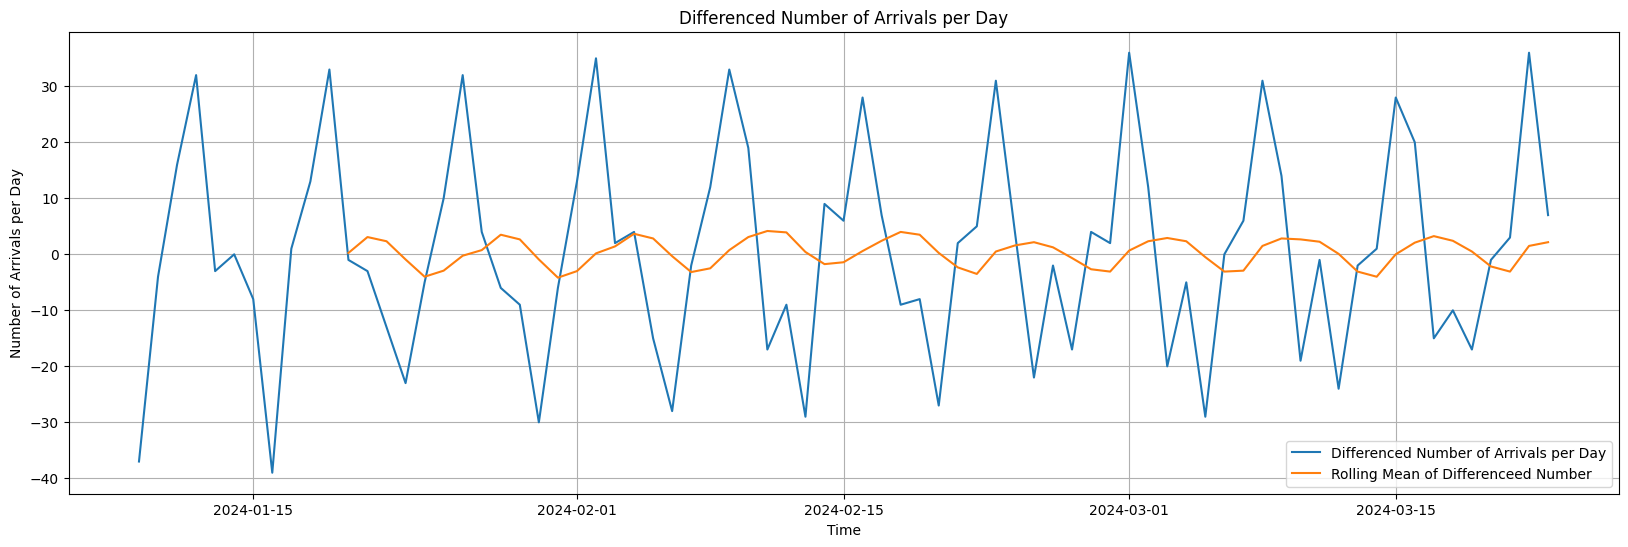

In [8]:
# Difference the data to remove the trend
df['arrivals_diff1'] = df['arrivals'].diff()

# Plot the differenced time series and it's rolling mean
plt.figure(figsize=(20, 6))
plt.plot(df["arrivals_diff1"], label='Differenced Number of Arrivals per Day')
plt.plot(df["arrivals_diff1"].rolling(window=12).mean(), label='Rolling Mean of Differenceed Number')
plt.title("Differenced Number of Arrivals per Day")
plt.xlabel('Time')
plt.ylabel('Number of Arrivals per Day')
plt.grid(True)
plt.legend()
plt.show()

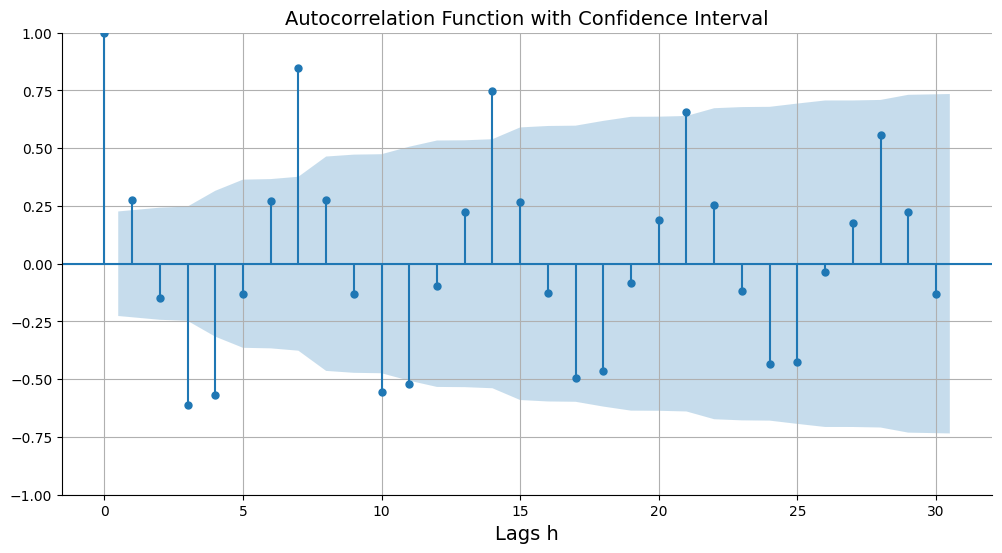

In [9]:
# Plot the autocorrelogram of the differenced time series
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df['arrivals_diff1'].dropna(), lags=30, alpha=0.05, ax=ax)

plt.xlabel('Lags h', fontsize = 14)
plt.title('Autocorrelation Function with Confidence Interval', fontsize = 14)
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

## Seasonal Differencing

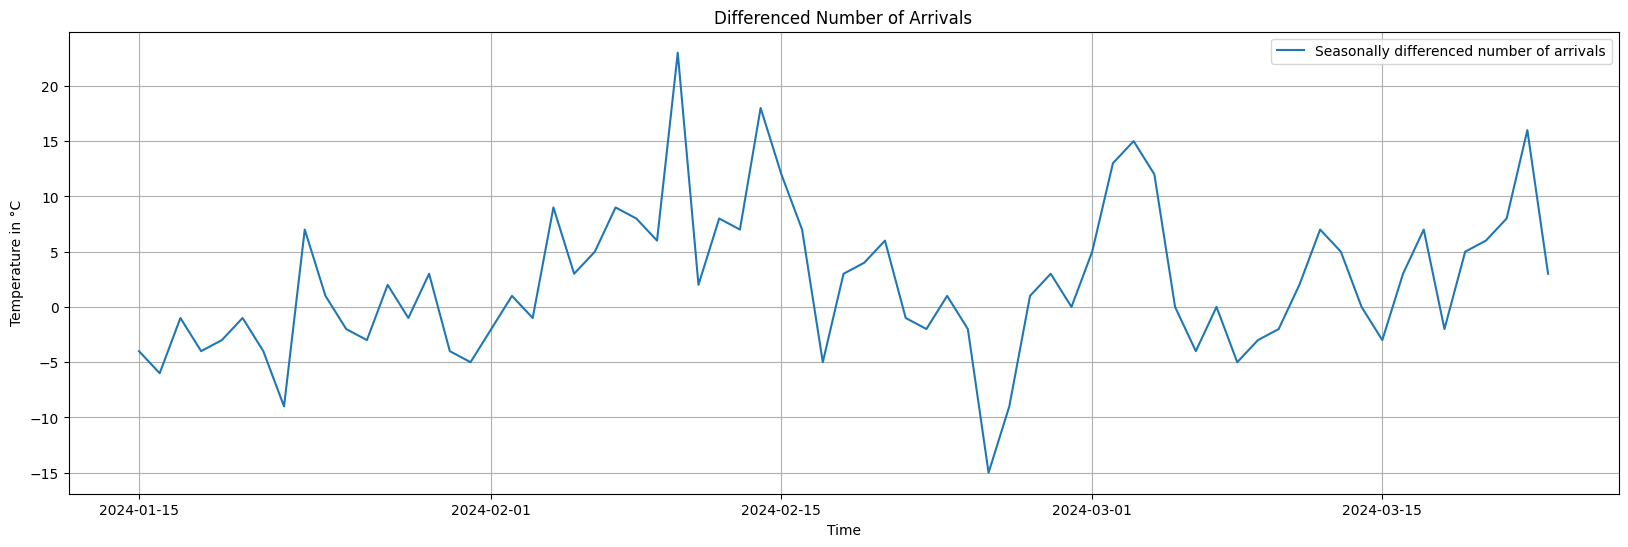

In [11]:
# Difference the original data get rid of seasonality
df['arrivals_diff7'] = df['arrivals'].diff(7)

# Plot the seasonally differenced time series
plt.figure(figsize=(20, 6))
plt.plot(df['arrivals_diff7'], label='Seasonally differenced number of arrivals')
plt.title("Differenced Number of Arrivals")
plt.xlabel('Time')
plt.ylabel('Temperature in °C')
plt.grid(True)
plt.legend()
plt.show()

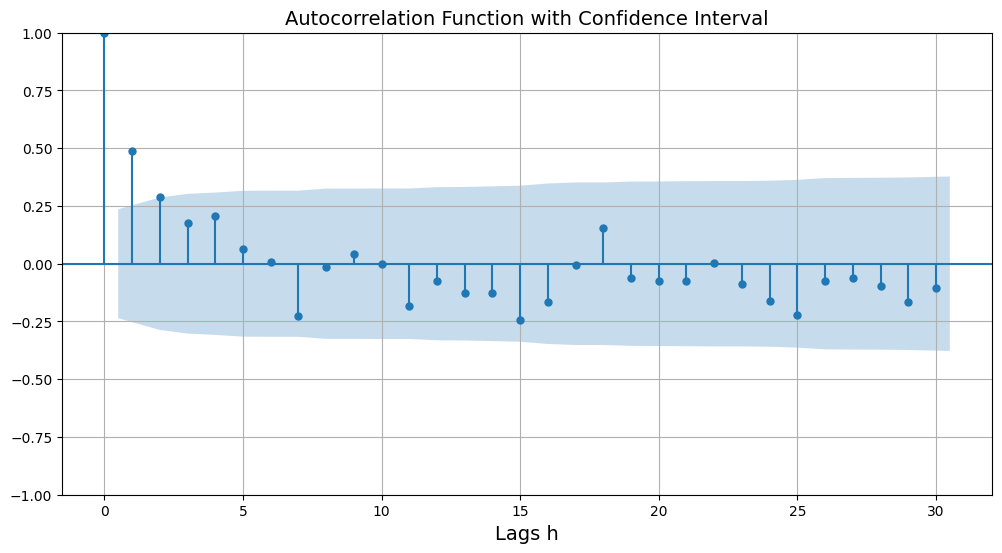

In [12]:
# Plot the autocorrelogram of the seasonally differenced time series
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df['arrivals_diff7'].dropna(), lags=30, alpha=0.05, ax=ax)

plt.xlabel('Lags h', fontsize = 14)
plt.title('Autocorrelation Function with Confidence Interval', fontsize = 14)
plt.grid(True)
plt.show()

## Combination of Differencing & Seasonal Differencing

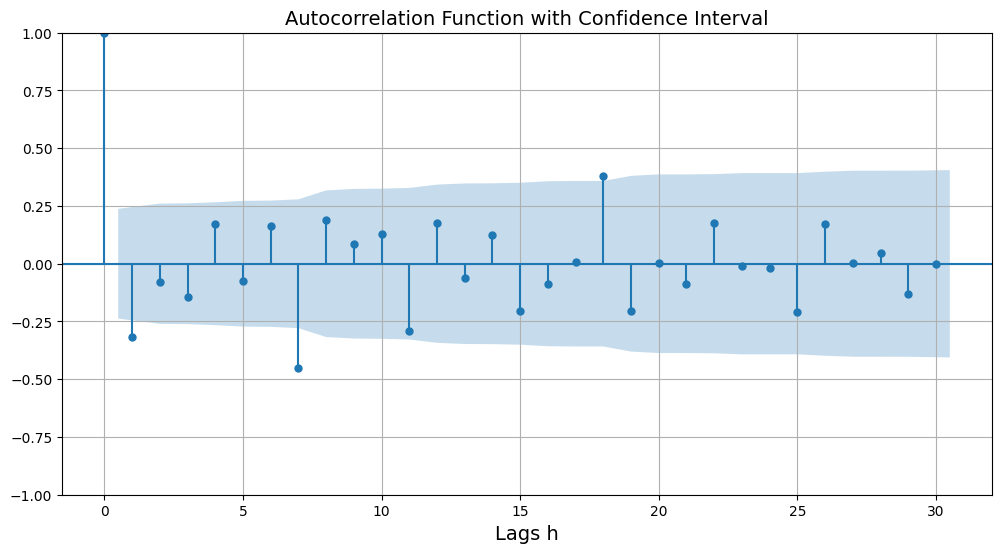

In [14]:
df['arrivals_stationary'] = df['arrivals_diff1'].diff(7)

# Plot the autocorrelogram of the seasonally differenced time series
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df['arrivals_stationary'].dropna(), lags=30, alpha=0.05, ax=ax)

plt.xlabel('Lags h', fontsize = 14)
plt.title('Autocorrelation Function with Confidence Interval', fontsize = 14)
plt.grid(True)
plt.show()

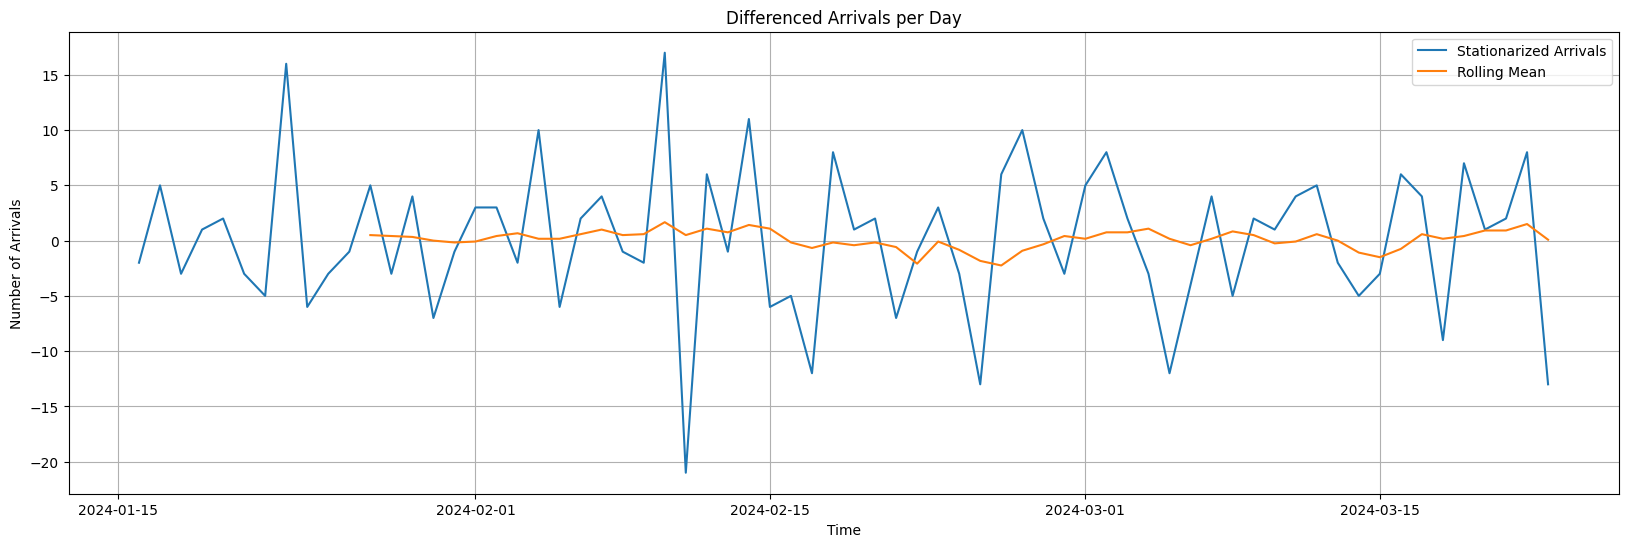

In [15]:
# Plot the stationarized time series
plt.figure(figsize=(20, 6))
plt.plot(df['arrivals_stationary'], label='Stationarized Arrivals')
plt.plot(df['arrivals_stationary'].rolling(window=12).mean(), label='Rolling Mean')
plt.title("Differenced Arrivals per Day")
plt.xlabel('Time')
plt.ylabel('Number of Arrivals')
plt.grid(True)
plt.legend()
plt.show()

## Test for Stationarity of Differenced Time Series

In [16]:
#Import KPSS test
from statsmodels.tsa.stattools import kpss

#Run KPSS test
stat, p_value, lags, critical_values = kpss(df['arrivals_stationary'].dropna(), regression='c', nlags="auto")

print(f"KPSS Statistic: {stat}")
print(f"p-value: {p_value}")

# Interpret the p-value
if p_value < 0.05:
    print("The time series is likely non-stationary (reject null hypothesis).")
else:
    print("The time series is likely stationary (fail to reject null hypothesis).")

KPSS Statistic: 0.10122011425659042
p-value: 0.1
The time series is likely stationary (fail to reject null hypothesis).


/var/folders/qb/sbb3fw8j7cx9jqvndn9vkgqw0000gp/T/ipykernel_26122/4134165570.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, critical_values = kpss(df['arrivals_stationary'].dropna(), regression='c', nlags="auto")
